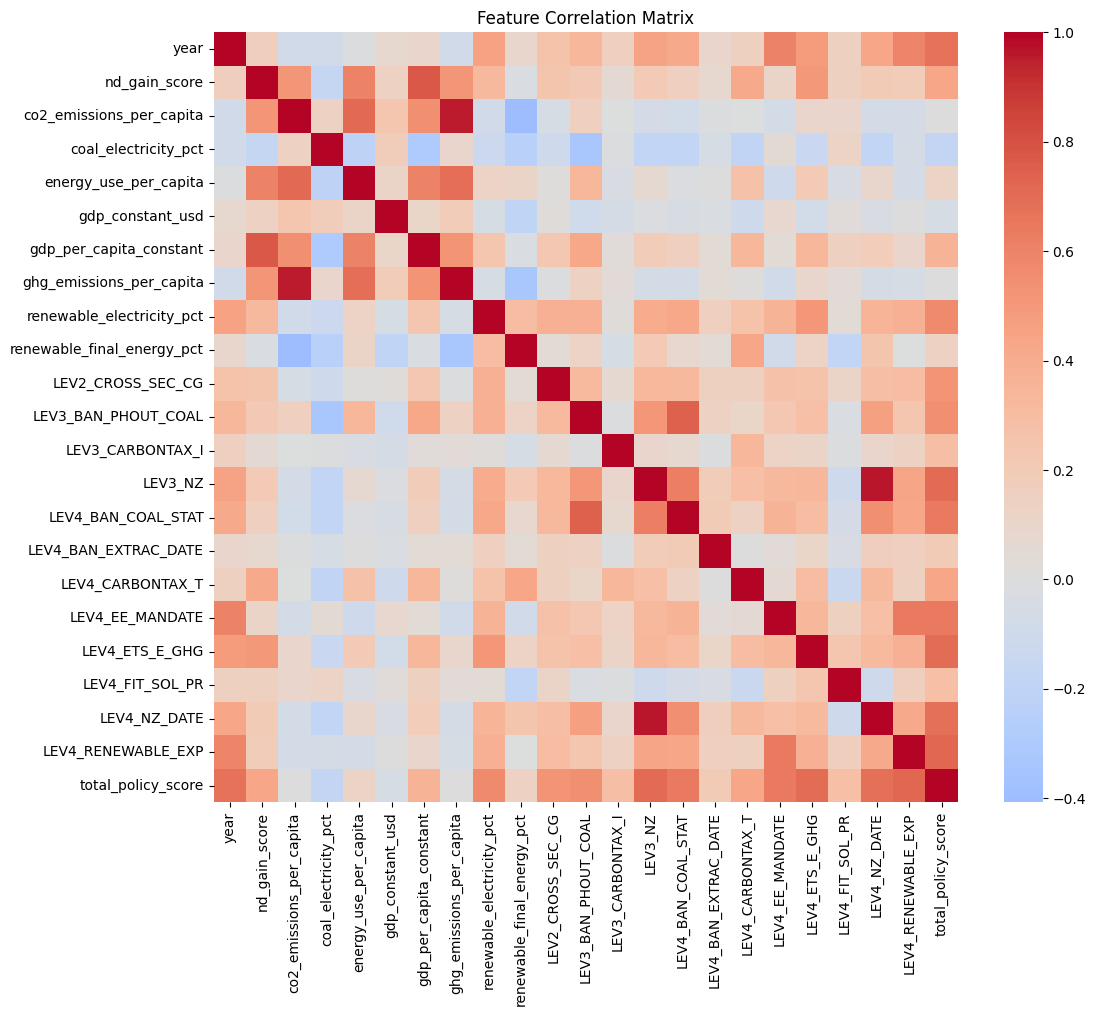

Low Variance Features to consider dropping:
Series([], dtype: float64)
Highly Correlated Features to consider dropping:
['ghg_emissions_per_capita', 'LEV4_NZ_DATE']


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('../../data/processed/final_feature_matrix.csv')

# Create a "policy score" by summing all the LEV features
lev_cols = [c for c in df.columns if 'LEV' in c]
df['total_policy_score'] = df[lev_cols].sum(axis=1)

# Check for Correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

# Distribution Check
# Look for features with very low variance (mostly zeros)
variance = df.var(numeric_only=True)
print("Low Variance Features to consider dropping:")
print(variance[variance < 0.1])

# Look for features that are highly correlated with each other (multicollinearity)
corr_matrix = df.corr(numeric_only=True).abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
print("Highly Correlated Features to consider dropping:")
print(high_corr)

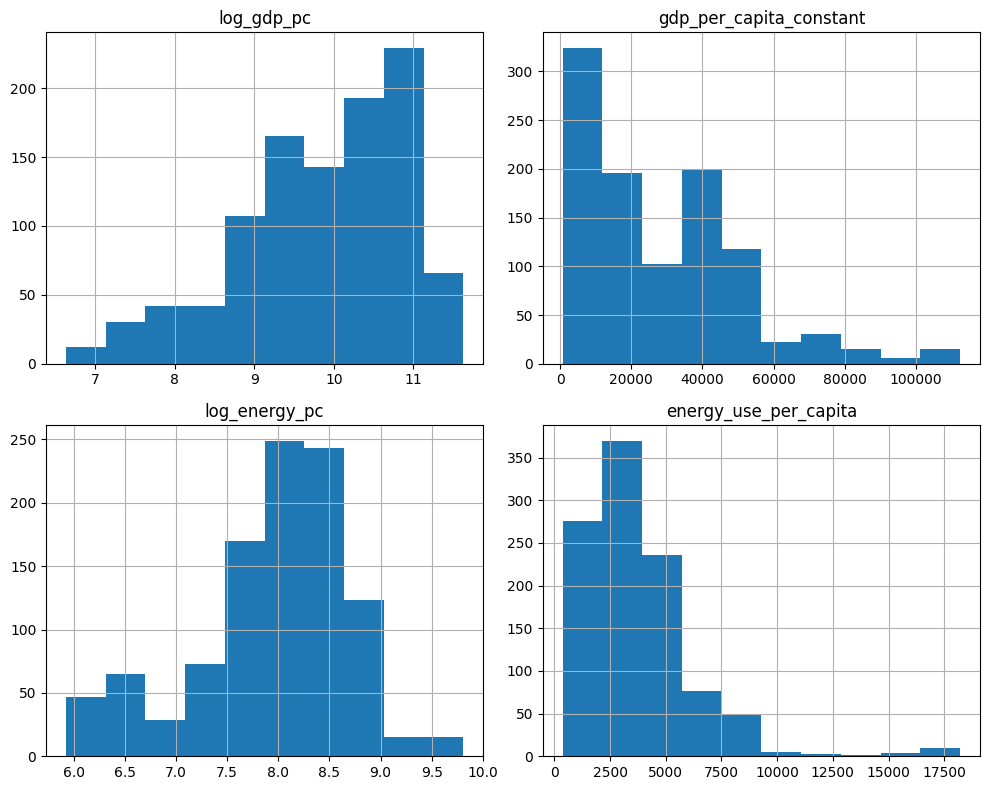

In [ ]:
import numpy as np

# Handle the negatives in percentages
pct_cols = ['renewable_electricity_pct', 'renewable_final_energy_pct', 'coal_electricity_pct']
for col in pct_cols:
    df[col] = df[col].clip(lower=0)

# Log-transform the skewed economic data
df['log_gdp_pc'] = np.log1p(df['gdp_per_capita_constant'])
df['log_energy_pc'] = np.log1p(df['energy_use_per_capita'])

# Create a "Climate Ambition" Proxy
# This combines renewable electricity and general policy effort
lev_cols = [c for c in df.columns if 'LEV' in c]
df['policy_score_norm'] = df[lev_cols].mean(axis=1)

# Drop the redundant absolute values
# Keeping the 'per capita' and 'log' versions for better clustering
df_clean = df.drop(columns=['gdp_constant_usd', 'gdp_per_capita_constant', 'energy_use_per_capita'])

# Drop the highly correlated features
# It is only LEV4_NZ_DATE
df_clean = df_clean.drop(columns = ['LEV4_NZ_DATE'])

# Quick check on the new distributions


df[['log_gdp_pc','gdp_per_capita_constant', 'log_energy_pc','energy_use_per_capita']].hist(figsize=(10,8))
plt.tight_layout()

# Save the plots for the report to outputs folder
plt.savefig('../outputs/distribution_plots.png')


# Save the cleaned and engineered dataset for clustering
df_clean.to_csv('../../data/processed/cleaned_feature_matrix.csv', index=False)